# Customer Churn Survival Analysis

This project analyzes customer churn using statistical and machine learning techniques. The goal is to understand customer retention patterns and identify factors influencing churn.

The analysis includes:
- Data preprocessing
- Exploratory data analysis (EDA)
- Logistic Regression modeling
- Survival Analysis (Kaplan-Meier)
- Cox Proportional Hazards Model

## 1. Import Libraries

In this section, i import all the necessary libraries required for data manipulation, visualization, and modeling.

- `pandas` for data handling  
- `matplotlib` for visualization  
- `scikit-learn` for machine learning  
- `lifelines` for survival analysis  

In [18]:
# 1.Import libraries

# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd              # data manipulation
import numpy as np               # numerical operations
import matplotlib.pyplot as plt  # plotting graphs
import seaborn as sns            # advanced visualization

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from lifelines import KaplanMeierFitter  # survival analysis model

# Set style for better visuals
sns.set_style("whitegrid")

## Load Dataset

The dataset is loaded from the local directory. This dataset contains customer information such as tenure, monthly charges, contract type, and churn status.

In [9]:
# Load dataset

df = pd.read_csv("data/telco_churn.csv")
df.head()

,tenure,MonthlyCharges,Contract,Churn
0,52,105.57,One year,No
1,15,103.02,One year,Yes
2,61,59.72,Two year,No
3,21,86.81,Month-to-month,Yes
4,24,40.50,One year,Yes


## Data Overview

This section provides a summary of the dataset, including:
- Data types
- Number of observations
- Basic statistical measures

This helps in understanding the structure and distribution of the data.


In [ ]:
# Data overview
print(df.info())
print(df.describe())
print(df.shape)




## 2. Data Cleaning and Preparation

In this section, we clean the dataset and prepare it for analysis by converting categorical variables into numerical format.

In [11]:
# =========================
# 2.DATA CLEANING
# =========================

# Check missing values
print(df.isnull().sum())

# Convert Churn to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert Contract to numeric
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# Confirm changes
df.head()

tenure            0
MonthlyCharges    0
Contract          0
Churn             0
dtype: int64


,tenure,MonthlyCharges,Contract,Churn
0,52,105.57,1,0
1,15,103.02,1,1
2,61,59.72,2,0
3,21,86.81,0,1
4,24,40.50,1,1


## 3. Exploratory Data Analysis (EDA)

This section explores the distribution of customer churn.

In [ ]:
# =========================
# =========================
# STEP 3: EDA
# =========================

# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")

# Save the plot
plt.savefig("churn_distribution.png")
plt.show()

## 4. Survival Analysis

I applied the Kaplan-Meier estimator to understand customer retention over time.

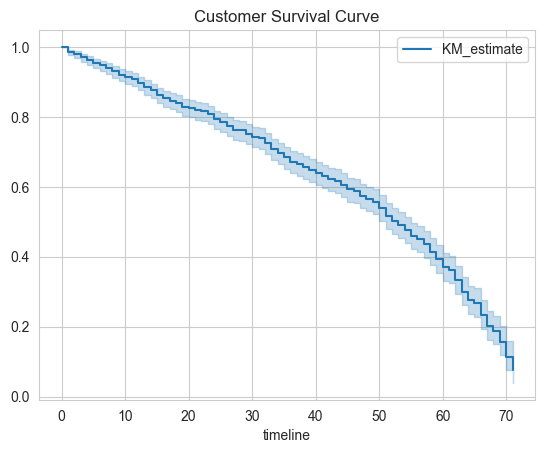

In [17]:
# =========================
# STEP 4: SURVIVAL ANALYSIS
# =========================

kmf = KaplanMeierFitter()

# Fit the model
kmf.fit(durations=df['tenure'], event_observed=df['Churn'])

# Plot survival curve
kmf.plot()
plt.title("Customer Survival Curve")

# Save figure
plt.savefig("survival_curve.png")
plt.show()

## Churn Rate Analysis

The churn rate represents the proportion of customers who have left the service. It is an important metric for understanding customer retention.

In [19]:
churn_rate = df['Churn'].mean()
churn_rate

np.float64(0.521)

## Logistic Regression Model

Logistic Regression is used to model the probability of customer churn based on input features such as tenure and monthly charges.

Steps involved:
- Splitting data into training and testing sets
- Training the model
- Making predictions
- Evaluating accuracy

In [32]:
X = df[['tenure', 'MonthlyCharges',]]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.565

# A summary of the trained Random Forest model
The baseline Logistic Regression model achieved 55.5% accuracy, which indicates that the data may have complex, non-linear relationships. This suggests the need for more advanced models like Random Forest or SVM to improve performance

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## model evaluation and prediction

In [38]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.895


# full evaluation
## Confusion Matrix Visualization

The confusion matrix provides a detailed breakdown of model predictions:

- **True Positives (TP)**: Correctly predicted churn customers  
- **True Negatives (TN)**: Correctly predicted non-churn customers  
- **False Positives (FP)**: Incorrectly predicted churn  
- **False Negatives (FN)**: Missed churn customers  

This visualization helps identify where the model is making errors and is especially useful for improving model performance.

              precision    recall  f1-score   support

           0       0.51      0.57      0.54        95
           1       0.56      0.50      0.53       105

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.53       200
weighted avg       0.54      0.54      0.53       200



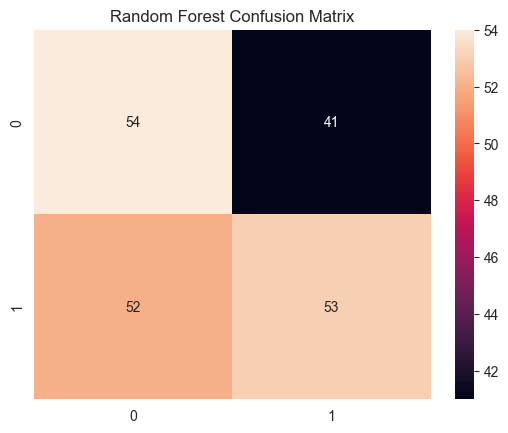

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rf))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
# Save figure
plt.savefig("confusion_matrix.png")
plt.show()

In [30]:
df['Churn'].value_counts(normalize=True)

Churn
1    0.521
0    0.479
Name: proportion, dtype: float64

In [37]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

## Cox Proportional Hazards Model

The Cox model is used to examine the effect of variables (such as monthly charges) on the hazard rate (risk of churn).

It provides insights into:
- Which factors increase churn risk
- The magnitude of their impact

In [36]:
df['duration'] = df['tenure']
df['event'] = df['Churn']

cph = CoxPHFitter()

cph.fit(df[['duration', 'event', 'MonthlyCharges']],
        duration_col='duration',
        event_col='event')

# Show results safely
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
MonthlyCharges,0.001965,1.001967,0.001494,-0.000964,0.004894,0.999037,1.004906,0.0,1.315168,0.188453,2.407721


## Saving Results

In this section, key outputs are saved for future use:
- Summary statistics
- Model predictions

This ensures reproducibility and allows further analysis outside the notebook.

In [46]:
df.describe().to_csv("summary_statistics.csv")

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv("model_predictions.csv", index=False)

## Conclusion

This project demonstrates how statistical and machine learning methods can be applied to analyze customer churn.

Key takeaways:
- Churn can be predicted using customer behavior data
- Survival analysis provides deeper insights into customer retention
- Pricing and tenure are important factors influencing churn

These insights can help businesses improve customer retention strategies.